---
title: "Financial Statistics -  Coursework"
author: Group 30
date: "23 November 2025"
institute: "Imperial Business School"
format:
  pdf:
    fig-cap-location: top
    include-in-header:
      text: |
        \usepackage[labelfont=bf,textfont=bf]{caption}   
execute:
  warning: false
  message: false
---
\newpage
\tableofcontents
\listoffigures
\listoftables
\newpage

In [25]:
# Load libraries
library(readxl)
library(lubridate)
library(readr)

# Question 1 - CAPM

## 1. Prepare the Dataset

In [26]:
# Use the dataset data coursework Q1
data_q1 <- read_excel("data_coursework_Q1.xls")


data_q1$date <- make_date(year = data_q1$year_, month = data_q1$month_, day = 1)
data_q1$IBM <- parse_number(data_q1$IBM)
df_q1 <- data_q1[, c("date","SP500", "IBM", "1-month Tbill")]

colnames(df_q1)[colnames(df_q1) == "1-month Tbill"] <- "Rf"
colnames(df_q1)[colnames(df_q1) == "IBM"] <- "Ri"

df_q1$Rm <- (df_q1$SP500 / dplyr::lag(df_q1$SP500)) - 1 
df_q1$Rf <- df_q1$Rf / 12 

head(df_q1,30)

New names:
• `` -> `...5`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...13`
• `` -> `...14`
Warning message:
“3 parsing failures.
row col expected   actual
  1  -- a number adjusted
  2  -- a number closed  
  3  -- a number pirce   
”


date,SP500,Ri,Rf,Rm
<date>,<dbl>,<dbl>,<dbl>,<dbl>
1960-01-01,58.03,NA,0.02750000,NA
1960-02-01,55.78,NA,0.02416667,-0.038773048
1960-03-01,55.02,NA,0.02916667,-0.013624955
1960-04-01,55.73,NA,0.01583333,0.012904398
1960-05-01,55.22,NA,0.02250000,-0.009151265
1960-06-01,57.26,NA,0.02000000,0.036943137
1960-07-01,55.84,NA,0.01083333,-0.024799162
1960-08-01,56.51,NA,0.01416667,0.011998567
1960-09-01,54.81,NA,0.01333333,-0.030083171


In [27]:
# Construct the measures

# excess return for IBM (Ri - Rf)
df_q1$ri_rf <- df_q1$Ri - df_q1$Rf
# excess market return (Rm - Rf)
df_q1$rm_rf <- df_q1$Rm - df_q1$Rf
# squared market excess return
df_q1$rm_rf_sq <- df_q1$rm_rf^2

# D_t = 1 if market excess return > 0, 0 otherwise
df_q1$D         <- ifelse(df_q1$rm_rf > 0, 1, 0)
df_q1$D_rm      <- df_q1$D       * df_q1$rm_rf
df_q1$Dinv_rm   <- (1 - df_q1$D) * df_q1$rm_rf

## 2. Estimate linear regression model

In [28]:
# Model 1: Standard CAPM
# ri_rf = alpha + beta * rm_rf + u
capm_model <- lm(ri_rf ~ rm_rf, data = df_q1)
# show summary
summary(capm_model)

# - Model 2: Extended CAPM
# ri_rf = alpha + beta1*D_rm + beta2*Dinv_rm + beta3*rm_rf_sq + u
ext_model <- lm(ri_rf ~ D_rm + Dinv_rm + rm_rf_sq, data = df_q1)
# show summary
summary(ext_model)


Call:
lm(formula = ri_rf ~ rm_rf, data = df_q1)

Residuals:
   Min     1Q Median     3Q    Max 
-8.878 -4.733 -2.628  7.244 19.250 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   9.8675     0.5256  18.775   <2e-16 ***
rm_rf        -5.0450     9.0589  -0.557    0.578    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.112 on 346 degrees of freedom
  (24 observations deleted due to missingness)
Multiple R-squared:  0.0008956,	Adjusted R-squared:  -0.001992 
F-statistic: 0.3101 on 1 and 346 DF,  p-value: 0.578



Call:
lm(formula = ri_rf ~ D_rm + Dinv_rm + rm_rf_sq, data = df_q1)

Residuals:
   Min     1Q Median     3Q    Max 
-9.040 -4.880 -2.794  6.682 19.697 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)    9.0742     0.8315  10.913   <2e-16 ***
D_rm          18.0443    51.6197   0.350   0.7269    
Dinv_rm      -49.9093    28.6993  -1.739   0.0829 .  
rm_rf_sq    -350.2208   196.2948  -1.784   0.0753 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.097 on 344 degrees of freedom
  (24 observations deleted due to missingness)
Multiple R-squared:  0.01081,	Adjusted R-squared:  0.002179 
F-statistic: 1.253 on 3 and 344 DF,  p-value: 0.2906


## 3. F-test for H0: β1 = β2

In [29]:
# Restricted model: force beta1 = beta2
# ri_rf = alpha + beta * rm_rf + beta3*rm_rf_sq + u
restricted_model <- lm(ri_rf ~ rm_rf + rm_rf_sq, data = df_q1)

# F-test between restricted and unrestricted models
anova(restricted_model, ext_model)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,345,17373.33,NA,NA,NA,NA
2,344,17328.28,1,45.04091,0.8941493,0.3450191


### Summary
The F-test compares the restricted symmetric CAPM model with the unrestricted asymmetric beta specification. The test statistic is F = 0.894 with a corresponding p-value of 0.345. Because the p-value is well above conventional significance levels (1%, 5%, or 10%), we fail to reject the null hypothesis that β₁ = β₂.

This implies that the market beta of IBM does not differ significantly between up-market periods (rm_rf > 0) and down-market periods (rm_rf ≤ 0). In other words, the data do not provide evidence of return asymmetry or different systematic risk exposures across market states. The standard CAPM with a single beta coefficient appears sufficient for this sample.

## 4. t-test for H0: α = 0 

In [30]:
# extract summary table
capm_summary <- summary(capm_model)$coefficients

# alpha estimate, t-value, p-value
alpha_est <- capm_summary["(Intercept)", "Estimate"]
alpha_t   <- capm_summary["(Intercept)", "t value"]
alpha_p   <- capm_summary["(Intercept)", "Pr(>|t|)"]

alpha_est
alpha_t
alpha_p

[1] 9.867469

[1] 18.77453

[1] 1.001308e-54

### Summary
The CAPM regression shows that the estimated alpha (intercept) for IBM is 9.87, with a t-statistic of 18.77 and a p-value effectively 0. This indicates that the abnormal return (Jensen’s alpha) is highly significant, meaning IBM delivered a large positive excess return that cannot be explained by market movements alone during the sample period. The null hypothesis α = 0 is strongly rejected.

# Question 2 - probability of a positive asset return

In [31]:
# Load the required package
library(readxl)
library(utils)

In [32]:
# Sub-question 2a: OLS regression over the whole sample period
# Load data
data <- read_excel("data_coursework_Q2.xls", sheet = 1)
data <- na.omit(data)
head(data)

# Separate response variable and regressors
returns <- data$ESR
regressors <- data[, -which(names(data) == "ESR" | names(data) == "mth")]

# Create binary response variable
Y <- ifelse(returns > 0, 1, 0)

# Prepare lead-lag data
Y_lead <- Y[-1]
X_lag  <- regressors[-length(Y), ]

reg_data <- data.frame(Y_lead, X_lag)

ols_model <- lm(Y_lead ~ ., data = reg_data)
summary(ols_model)

mth,ESR,USR,EIF,ERECB,EFX,EDY,ESP,UIF,URR,UDY,UOIL
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
31-gen-85,0.0559,0.0690,0.0209,1.6094,0.0025,1.1663,2.206,0.0396,2.1668,1.4951,0.0210
31106,0.0331,0.0066,0.0235,1.6582,0.0556,1.1474,2.374,0.0347,2.1679,1.4929,0.0094
31137,-0.0027,-0.0089,0.0249,1.6582,-0.0813,1.1474,2.142,0.0354,2.1494,1.5041,0.0582
31167,0.0226,-0.0057,0.0250,1.6582,0.0049,1.1569,2.023,0.0372,2.1494,1.5173,-0.0269
31-mag-85,0.0424,0.0504,0.0236,1.6582,-0.0127,1.1282,1.856,0.0352,2.0334,1.4679,0.0108
30-giu-85,0.0263,0.0116,0.0193,1.6582,-0.0099,1.1019,1.753,0.0351,2.0732,1.4563,-0.0347



Call:
lm(formula = Y_lead ~ ., data = reg_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9505 -0.4431  0.1862  0.3995  0.9720 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.44284    0.30703   1.442 0.150325    
USR           1.04566    0.62401   1.676 0.094915 .  
EIF           8.59691    3.88055   2.215 0.027541 *  
ERECB        -0.62801    0.15006  -4.185 3.83e-05 ***
EFX           0.94970    0.88001   1.079 0.281431    
EDY           0.58948    0.28929   2.038 0.042525 *  
ESP          -0.06447    0.03875  -1.664 0.097318 .  
UIF         -12.32022    3.70983  -3.321 0.001017 ** 
URR           0.42052    0.09377   4.485 1.07e-05 ***
UDY           0.10158    0.16057   0.633 0.527482    
UOIL         -0.95801    0.28501  -3.361 0.000884 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4675 on 279 degrees of freedom
Multiple R-squared:  0.1352,	Adjusted R-squared:  0.1042 
F-statisti

The model is statistically significant (p < 0.001), and although the adjusted $R^2$ of around 10% indicates a modest explanatory power, it suggests that the included predictors have a meaningful impact on the likelihood of achieving a positive return. Several predictors—including EIF, EDY, and URR—significantly increase the probability of a positive return, while variables such as ERECB, UIF, and UOIL significantly reduce it.

In [33]:
# sub-question 2b: Compute Z(alpha=1/2) for all possible
# models and search for best predictors combination
# Compute predicted probabilities
P_hat <- predict(ols_model, type = "response")

# Construct Z_t(alpha=1/2)
alpha <- 0.5
returns_t <- returns[-1]
Z_t <- ifelse((P_hat > alpha & returns_t > 0) |
              (P_hat <= alpha & returns_t <= 0), 1, 0)

# overall hit ratio
Z_alpha <- mean(Z_t)
cat("Z(alpha = 0.5) for full model =", Z_alpha, "\n")

# Search for best combination of predictors that maximizes Z(1/2)
predictor_names <- names(X_lag)
k <- length(predictor_names)

cat("Number of predictors:", k, "\n")

compute_Z <- function(vars) {
  if (length(vars) == 0) {
    model <- lm(Y_lead ~ 1, data = reg_data)
  } else {
    fmla <- as.formula(paste("Y_lead ~", paste(vars, collapse = "+")))
    model <- lm(fmla, data = reg_data)
  }
  Ph <- predict(model, type = "response")
  Zt <- ifelse((Ph > alpha & returns_t > 0) |
               (Ph <= alpha & returns_t <= 0), 1, 0)
  return(list(Z = mean(Zt), model = model, vars = vars))
}

best <- list(Z = -Inf, vars = NULL, model = NULL)

for (m in 1:k) {
  combs <- combn(predictor_names, m, simplify = FALSE)
  for (vars in combs) {
    res <- compute_Z(vars)
    if (res$Z > best$Z) {
      best <- res
    }
  }
}

# compare with intercept-only model
res0 <- compute_Z(character(0))
if (res0$Z > best$Z) {
  best <- res0
}
cat("Best Z(alpha=0.5) =", best$Z, "\n")
cat("Best predictor combination:\n")
print(best$vars)

Z(alpha = 0.5) for full model = 0.6655172 
Number of predictors: 10 


Best Z(alpha=0.5) = 0.6896552 
Best predictor combination:
[1] "USR"   "EIF"   "ERECB" "EFX"   "EDY"   "ESP"   "UIF"   "URR"  


In [34]:
print(summary(best$model))


Call:
lm(formula = fmla, data = reg_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.9325 -0.4699  0.2351  0.4077  0.7228 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.29068    0.19988   1.454 0.146976    
USR          1.23219    0.63004   1.956 0.051488 .  
EIF          5.83448    3.58057   1.629 0.104331    
ERECB       -0.53419    0.12939  -4.129 4.82e-05 ***
EFX          1.00195    0.89248   1.123 0.262544    
EDY          0.70824    0.18753   3.777 0.000194 ***
ESP         -0.06407    0.03804  -1.684 0.093198 .  
UIF         -9.83058    3.69086  -2.663 0.008180 ** 
URR          0.39804    0.08565   4.647 5.18e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4756 on 281 degrees of freedom
Multiple R-squared:  0.09852,	Adjusted R-squared:  0.07285 
F-statistic: 3.839 on 8 and 281 DF,  p-value: 0.0002641



The model selected through maximizing the Z($\alpha$=0.5) achieves a performance of 0.6897, which is higher than the full model’s value of 0.6655. This improvement indicates that removing less informative predictors enhances forecasting accuracy. The optimal set of eight predictors—USR, EIF, ERECB, EFX, EDY, ESP, UIF, and URR—captures the majority of the predictive power while avoiding unnecessary noise from weaker variables. Statistically, the reduced model remains jointly significant (F-statistic p < 0.001), confirming that the selected predictors provide meaningful explanatory value. Several variables, such as ERECB, EDY, UIF, and URR, exhibit strong statistical significance. Although the adjusted $R^2$ is 7.3%, slightly lower than the full model.

Optimal alpha that maximizes Z(alpha):
alpha* = 0.4945 
Maximized Z(alpha*) = 0.6896552 


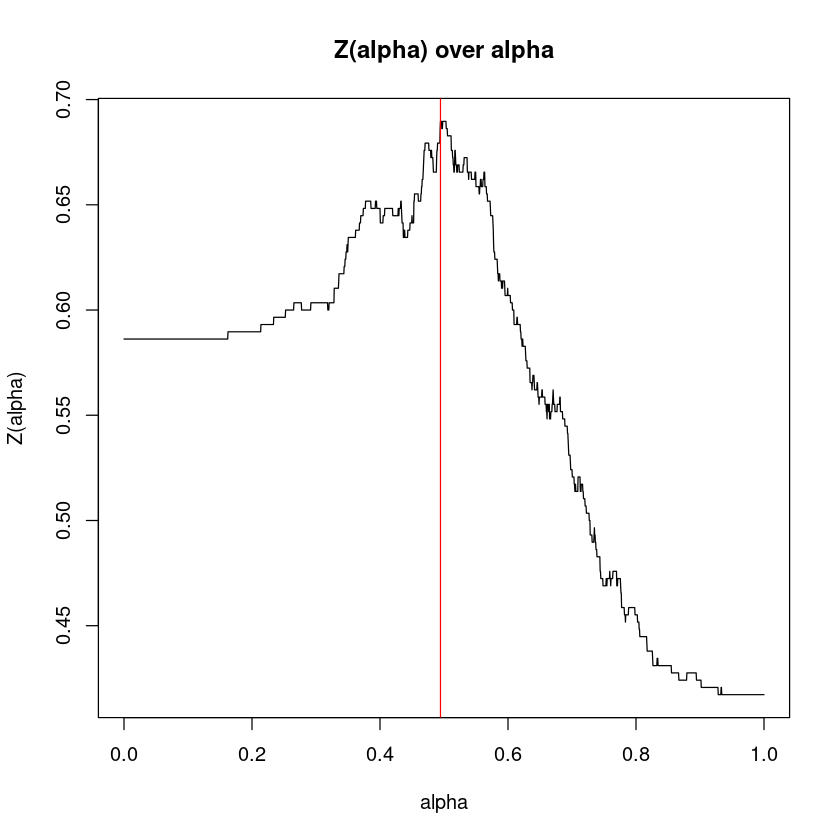

In [35]:
# sub-question 2c: Search for optimal alpha that maximizes Z(alpha)
# Extract predictions from the best model found earlier
P_best <- predict(best$model, type = "response")

# Search grid for alpha
alpha_grid <- seq(0, 1, length.out = 2001)

Z_alpha_vec <- numeric(length(alpha_grid))

for (i in seq_along(alpha_grid)) {
  a <- alpha_grid[i]
  Z_t_a <- ifelse((P_best > a & returns_t > 0) |
                  (P_best <= a & returns_t <= 0), 1, 0)
  Z_alpha_vec[i] <- mean(Z_t_a)
}

# find maximizing alpha
idx_max <- which.max(Z_alpha_vec)
alpha_best <- alpha_grid[idx_max]
Z_best_alpha <- Z_alpha_vec[idx_max]

cat("Optimal alpha that maximizes Z(alpha):\n")
cat("alpha* =", alpha_best, "\n")
cat("Maximized Z(alpha*) =", Z_best_alpha, "\n")

# Plot Z(alpha)
plot(alpha_grid, Z_alpha_vec, type="l",
     main="Z(alpha) over alpha",
     xlab="alpha", ylab="Z(alpha)")
abline(v = alpha_best, col = "red", lwd = )

# Question 3 - CIR model for the term structure of interest rate

In [36]:
# load required libraries
suppressPackageStartupMessages({
  library(tidyverse)
  library(numDeriv)
  library(MASS)
})

In [37]:
data <- read_excel("data_coursework_Q3.xls") %>%
  rename(date = `...1`, r_US = `T r_$`, r_UK = `T r_£`) %>%
  arrange(date) %>%
  drop_na() %>%
  mutate(across(c(r_US, r_UK), ~ ifelse(.x <= 0, NA_real_, .x))) %>%
  drop_na()


New names:
• `` -> `...1`


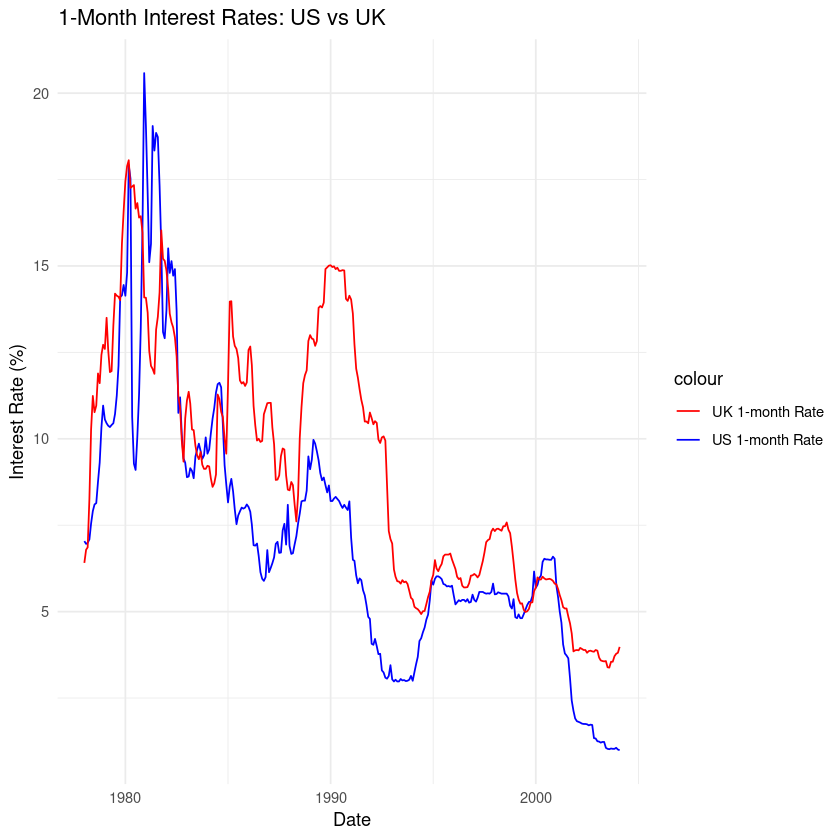

In [38]:
# plot interest rates of US and UK
library(ggplot2)
ggplot(data, aes(x = date)) +
  geom_line(aes(y = r_US, color = "US 1-month Rate")) +
  geom_line(aes(y = r_UK, color = "UK 1-month Rate")) +
  labs(title = "1-Month Interest Rates: US vs UK",
       x = "Date",
       y = "Interest Rate (%)") +
  scale_color_manual(values = c("US 1-month Rate" = "blue", "UK 1-month Rate" = "red")) +
  theme_minimal()

In [39]:
# Load required packages
suppressPackageStartupMessages(library(quantmod))
suppressPackageStartupMessages(library(MASS))
suppressPackageStartupMessages(library(Matrix))
suppressPackageStartupMessages(library(numDeriv))

# Extract interest rate data
r_US <- data$r_US  # US 1-month rate
r_UK <- data$r_UK  # UK 1-month rate

# Define log-likelihood for the CIR model
loglik_CIR <- function(theta, r) {
  mu <- theta[1]
  phi <- theta[2]
  sigma2 <- theta[3]
  
  T <- length(r)
  r_t <- r[2:T]
  r_t1 <- r[1:(T-1)]
  
  # Avoid numerical issues
  sigma2 <- max(sigma2, 1e-8)
  phi <- max(min(phi, 0.999), -0.999)
  
  # Calculate log-likelihood
  loglik <- -0.5 * log(2 * pi * r_t1 * sigma2) - 
    (r_t - mu * (1 - phi) - phi * r_t1)^2 / (2 * r_t1 * sigma2)
  
  # Return negative log-likelihood (for minimization)
  return(-sum(loglik, na.rm = TRUE))
}

# Define log-likelihood for the Vasicek model
loglik_Vasicek <- function(theta, r) {
  mu <- theta[1]
  phi <- theta[2]
  sigma2 <- theta[3]
  
  T <- length(r)
  r_t <- r[2:T]
  r_t1 <- r[1:(T-1)]
  
  # Avoid numerical issues
  sigma2 <- max(sigma2, 1e-8)
  phi <- max(min(phi, 0.999), -0.999)
  
  # Calculate log-likelihood
  loglik <- -0.5 * log(2 * pi * sigma2) - 
    (r_t - mu * (1 - phi) - phi * r_t1)^2 / (2 * sigma2)
  
  # Return negative log-likelihood
  return(-sum(loglik, na.rm = TRUE))
}

# Compute numerical Hessian
compute_hessian <- function(theta, loglik_func, r) {
  hess <- numDeriv::hessian(loglik_func, theta, r = r)
  return(hess)
}

# Estimation function
estimate_model <- function(r, model_name = "CIR") {
  # Initial parameter values
  init_params <- c(mean(r), 0.8, var(r))
  
  # Select model
  if (model_name == "CIR") {
    loglik_func <- loglik_CIR
    # Parameter constraints: mu > 0, 0 < phi < 1, sigma2 > 0
    lower_bounds <- c(1e-4, 1e-4, 1e-8)
    upper_bounds <- c(Inf, 0.999, Inf)
  } else {
    loglik_func <- loglik_Vasicek
    lower_bounds <- c(-Inf, -0.999, 1e-8)
    upper_bounds <- c(Inf, 0.999, Inf)
  }
  
  # Maximum likelihood estimation
  result <- optim(
    par = init_params,
    fn = loglik_func,
    r = r,
    method = "L-BFGS-B",
    lower = lower_bounds,
    upper = upper_bounds,
    hessian = TRUE
  )
  
  # Extract estimation results
  theta_hat <- result$par
  loglik_value <- -result$value
  hessian <- result$hessian
  
  # Calculate asymptotic covariance matrix
  if (rcond(hessian) > 1e-12) {
    asymp_cov <- solve(hessian)
    # Ensure covariance matrix is symmetric positive definite
    asymp_cov <- nearPD(asymp_cov)$mat
  } else {
    warning("Hessian matrix is near singular, using generalized inverse")
    asymp_cov <- ginv(hessian)
  }
  
  # Standard errors
  std_errors <- sqrt(diag(asymp_cov))
  
  # t-statistics
  t_stats <- theta_hat / std_errors
  
  # Results summary
  results <- list(
    parameters = theta_hat,
    std_errors = std_errors,
    t_stats = t_stats,
    loglik = loglik_value,
    asymp_cov = asymp_cov,
    hessian = hessian,
    convergence = result$convergence
  )
  
  return(results)
}

# Model comparison function
compare_models <- function(cir_results, vasicek_results) {
  comparison <- data.frame(
    Model = c("CIR", "Vasicek"),
    LogLik = c(cir_results$loglik, vasicek_results$loglik),
    AIC = c(
      -2 * cir_results$loglik + 2 * 3,
      -2 * vasicek_results$loglik + 2 * 3
    ),
    BIC = c(
      -2 * cir_results$loglik + 3 * log(length(r_US) - 1),
      -2 * vasicek_results$loglik + 3 * log(length(r_US) - 1)
    )
  )
  
  return(comparison)
}



In [40]:
# Estimate models for US interest rates
cat("=== American Interest Rates ===\n")
cir_us <- estimate_model(r_US, "CIR")
vasicek_us <- estimate_model(r_US, "Vasicek")

# Output results
print_results <- function(results, country, model) {
  cat(sprintf("\n%s %s model estimation results:\n", country, model))
  cat("Parameter estimates:\n")
  estimates <- data.frame(
    Parameter = c("mu", "phi", "sigma2"),
    Estimate = results$parameters,
    StdError = results$std_errors,
    tStat = results$t_stats
  )
  print(estimates)
  cat(sprintf("Log-likelihood: %.4f\n", results$loglik))
  cat(sprintf("Convergence status: %d\n", results$convergence))
}

print_results(cir_us, "US", "CIR")
print_results(vasicek_us, "US", "Vasicek")

=== American Interest Rates ===



US CIR model estimation results:
Parameter estimates:
  Parameter   Estimate     StdError        tStat
1        mu 0.00010000 10.898336613 9.175712e-06
2       phi 0.99730042  0.002530594 3.940974e+02
3    sigma2 0.04373302  0.001089834 4.012816e+01
Log-likelihood: -236.9732
Convergence status: 0

US Vasicek model estimation results:
Parameter estimates:
  Parameter  Estimate   StdError     tStat
1        mu 5.8889468 2.92671969  2.012132
2       phi 0.9847641 0.01110412 88.684566
3    sigma2 0.5601000 0.04477204 12.510038
Log-likelihood: -353.4131
Convergence status: 0


In [41]:
cat("=== UK Interest Rates ===\n")
cir_uk <- estimate_model(r_UK, "CIR")
vasicek_uk <- estimate_model(r_UK, "Vasicek")

print_results(cir_uk, "UK", "CIR")
print_results(vasicek_uk, "UK", "Vasicek")

=== UK Interest Rates ===



UK CIR model estimation results:
Parameter estimates:
  Parameter   Estimate     StdError        tStat
1        mu 8.99627775 5.573881e-06 1.614006e+06
2       phi 0.99721507 6.987061e-03 1.427231e+02
3    sigma2 0.02468564 1.963883e-03 1.256981e+01
Log-likelihood: -198.1268
Convergence status: 0

UK Vasicek model estimation results:
Parameter estimates:
  Parameter  Estimate    StdError      tStat
1        mu 9.1633582 4.225711012   2.168477
2       phi 0.9929275 0.007994119 124.207245
3    sigma2 0.2585271 0.020669879  12.507433
Log-likelihood: -232.4193
Convergence status: 0


In [42]:
# Model comparison
cat("\n=== Model Comparison ===\n")
comparison_us <- compare_models(cir_us, vasicek_us)
comparison_uk <- compare_models(cir_uk, vasicek_uk)

cat("US Interest Rate Model Comparison:\n")
print(comparison_us)

cat("\nUK Interest Rate Model Comparison:\n")
print(comparison_uk)


=== Model Comparison ===


US Interest Rate Model Comparison:
    Model    LogLik      AIC      BIC
1     CIR -236.9732 479.9464 491.1850
2 Vasicek -353.4131 712.8262 724.0648

UK Interest Rate Model Comparison:
    Model    LogLik      AIC      BIC
1     CIR -198.1268 402.2537 413.4923
2 Vasicek -232.4193 470.8387 482.0773


In [43]:
# Output asymptotic covariance matrices
cat("\n=== Asymptotic covariance matrices ===\n")
cat("US CIR Model:\n")
print(cir_us$asymp_cov)

cat("\nUS Vasicek Model:\n")
print(vasicek_us$asymp_cov)

cat("\nUK CIR Model:\n")
print(cir_uk$asymp_cov)

cat("\nUK Vasicek Model:\n")
print(vasicek_uk$asymp_cov)


=== Asymptotic covariance matrices ===
US CIR Model:
3 x 3 Matrix of class "dpoMatrix"
              [,1]          [,2]          [,3]
[1,]  1.187737e+02 -2.533012e-02  8.096863e-04
[2,] -2.533012e-02  6.403906e-06 -1.726767e-07
[3,]  8.096863e-04 -1.726767e-07  1.187737e-06

US Vasicek Model:
3 x 3 Matrix of class "dpoMatrix"
              [,1]          [,2]          [,3]
[1,]  8.565688e+00 -1.027894e-02 -2.998429e-06
[2,] -1.027894e-02  1.233015e-04  4.344832e-09
[3,] -2.998429e-06  4.344832e-09  2.004536e-03

UK CIR Model:


3 x 3 Matrix of class "dpoMatrix"
              [,1]          [,2]          [,3]
[1,]  3.106815e-11 -3.864257e-08 -2.060351e-11
[2,] -3.864257e-08  4.881902e-05  4.451122e-09
[3,] -2.060351e-11  4.451122e-09  3.856837e-06

UK Vasicek Model:
3 x 3 Matrix of class "dpoMatrix"
             [,1]         [,2]         [,3]
[1,] 17.856633554 9.243223e-03 1.893588e-03
[2,]  0.009243223 6.390594e-05 9.795309e-07
[3,]  0.001893588 9.795309e-07 4.272439e-04


In [44]:
# Prediction function - Generate one-step-ahead predictions
generate_predictions <- function(model_results, r, model_type) {
  mu <- model_results$parameters[1]
  phi <- model_results$parameters[2]
  
  T <- length(r)
  r_t1 <- r[1:(T-1)]  # 滞后一期值
  
  if (model_type == "CIR") {
    # CIR model prediction: conditional expectation
    predictions <- mu * (1 - phi) + phi * r_t1
  } else {
    # Vasicek model prediction: conditional expectation
    predictions <- mu * (1 - phi) + phi * r_t1
  }
  
  return(predictions)
}

# Generate in-sample predictions
cir_pred_us <- generate_predictions(cir_us, r_US, "CIR")
vasicek_pred_us <- generate_predictions(vasicek_us, r_US, "Vasicek")

cir_pred_uk <- generate_predictions(cir_uk, r_UK, "CIR") 
vasicek_pred_uk <- generate_predictions(vasicek_uk, r_UK, "Vasicek")

# Create prediction results data frame
actual_us <- r_US[2:length(r_US)]
actual_uk <- r_UK[2:length(r_UK)]

prediction_results <- data.frame(
  Date = data$date[2:nrow(data)],
  Actual_US = actual_us,
  CIR_Pred_US = cir_pred_us,
  Vasicek_Pred_US = vasicek_pred_us,
  Actual_UK = actual_uk,
  CIR_Pred_UK = cir_pred_uk,
  Vasicek_Pred_UK = vasicek_pred_uk
)


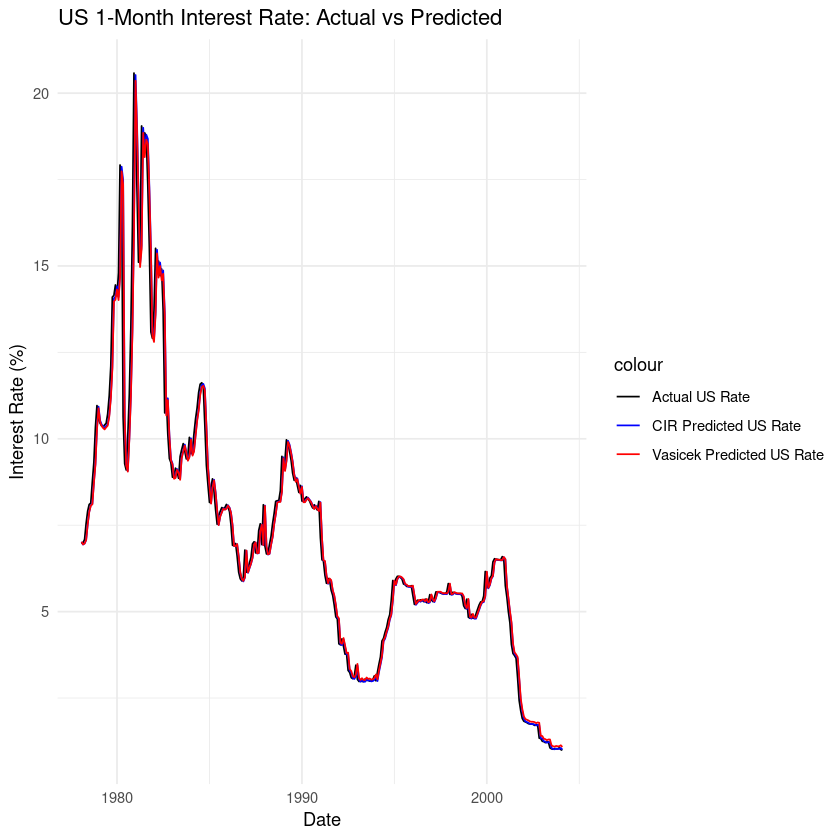

In [45]:
# plot predictions vs actuals for US
library(ggplot2)
ggplot(prediction_results, aes(x = Date)) +
  geom_line(aes(y = Actual_US, color = "Actual US Rate")) +
  geom_line(aes(y = CIR_Pred_US, color = "CIR Predicted US Rate")) +
  geom_line(aes(y = Vasicek_Pred_US, color = "Vasicek Predicted US Rate")) +
  labs(title = "US 1-Month Interest Rate: Actual vs Predicted",
       x = "Date",
       y = "Interest Rate (%)") +
  scale_color_manual(values = c("Actual US Rate" = "black",
                                 "CIR Predicted US Rate" = "blue",
                                 "Vasicek Predicted US Rate" = "red")) +
  theme_minimal() 

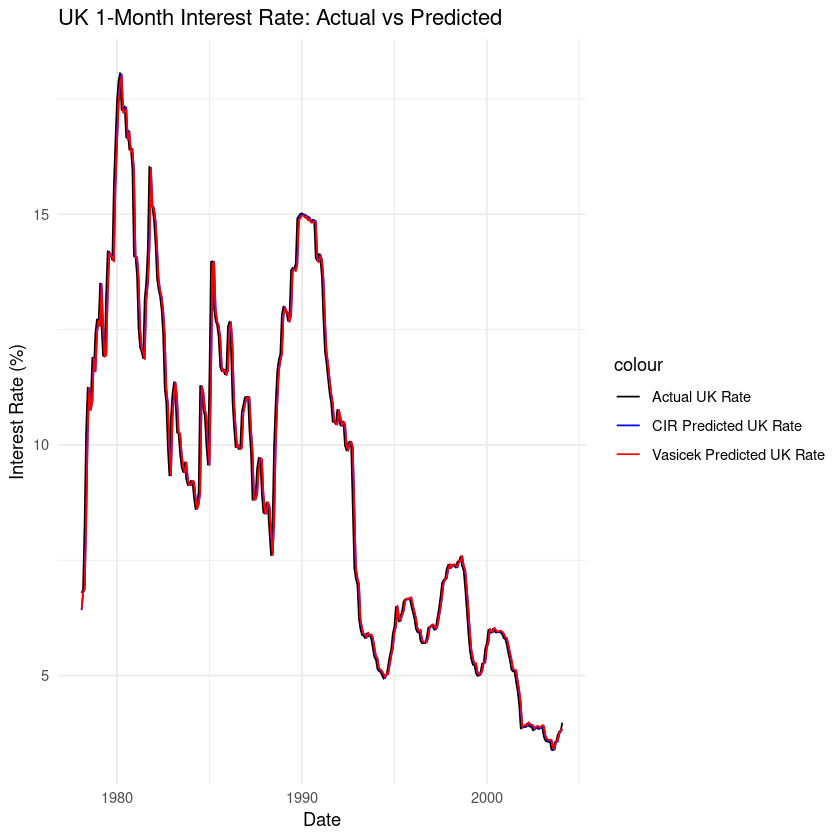

In [46]:
# plot prediction results for UK
ggplot(prediction_results, aes(x = Date)) +
  geom_line(aes(y = Actual_UK, color = "Actual UK Rate")) +
  geom_line(aes(y = CIR_Pred_UK, color = "CIR Predicted UK Rate")) +
  geom_line(aes(y = Vasicek_Pred_UK, color = "Vasicek Predicted UK Rate")) +
  labs(title = "UK 1-Month Interest Rate: Actual vs Predicted",
       x = "Date",
       y = "Interest Rate (%)") +
  scale_color_manual(values = c("Actual UK Rate" = "black",
                                 "CIR Predicted UK Rate" = "blue",
                                 "Vasicek Predicted UK Rate" = "red")) +
  theme_minimal()

### Analysis of CIR and Vasicek Models
Based on the estimation results, the CIR model demonstrates superior statistical fit compared to the Vasicek model in both the US and UK interest rate data, with higher log-likelihood values (US: -236.97 vs -353.41; UK: -198.13 vs -232.42) and lower AIC and BIC values, indicating that the CIR model can better capture the dynamics of interest rates, especially given its characteristic that volatility is related to the level of interest rates, which is more in line with the reality that interest rate fluctuations tend to be amplified at higher levels in the real financial market. 

However, the parameter estimation of the US CIR model shows instability, such as the long-term mean μ being close to zero and having a very large standard error, which may reflect the significant fluctuations in US interest rates during the sample period since 1978 (such as during the oil crisis and periods of inflationary pressure), making model identification difficult. 

In contrast, the parameter estimation of the UK CIR model is more stable, partly due to the relatively mild volatility of UK interest rates during this period, influenced by its stricter financial regulation and gradual monetary policy. Although the Vasicek model has more stable parameter estimation, its assumption of constant volatility limits its goodness of fit, especially in the highly volatile US environment. 

Overall, the theoretical advantages of the CIR model are statistically verified, but its practical application requires careful handling of parameter uncertainty in light of the specific financial background of each country.